# Classification baselines: many model families

This notebook expands the food-insecurity classification workflow with a broad baseline set. It uses the synthetic household food and housing insecurity dataset as the example and predicts `food_insecure_label`.

The default sample caps are intentionally small because RBF SVM, k-nearest neighbors, QDA, MLP, and the PyTorch baseline can become slow on 100,000 rows. After the notebook runs once, increase the sample constants if more compute is available.

In [1]:
# Keep CPU-threaded estimators stable in notebooks.
# Set these before importing scikit-learn.
import os
os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("MKL_NUM_THREADS", "1")
os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")

from pathlib import Path
import time
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

DATA_CANDIDATES = [
    Path("synthetic_food_housing_insecurity_100k.csv"),
    Path("../synthetic_food_housing_insecurity_100k.csv"),
    Path("/mnt/data/synthetic_food_housing_insecurity_100k.csv"),
]
DATA_PATH = next((p for p in DATA_CANDIDATES if p.exists()), None)
assert DATA_PATH is not None, "Dataset CSV not found. Put synthetic_food_housing_insecurity_100k.csv beside this notebook or one folder above."

df = pd.read_csv(DATA_PATH)
print("Dataset path:", DATA_PATH)
print("Shape:", df.shape)
df.head()

Dataset path: ../synthetic_food_housing_insecurity_100k.csv
Shape: (100000, 52)


,household_id,survey_year,state,region,urbanicity,household_size,adults_count,children_count,children_present,single_parent,head_age_group,senior_present,disability_present,race_ethnicity,immigrant_household,primary_language,education_level,employment_status,industry_sector,monthly_income_usd,income_to_poverty_ratio,income_volatility,savings_buffer_days,debt_to_income_pct,credit_access,housing_status,monthly_housing_cost_usd,rent_or_mortgage_burden_pct,behind_on_housing_payment,eviction_or_foreclosure_risk,utility_shutoff_notice,housing_insecure_label,benefits_snap,benefits_wic,free_school_meals,transportation_access,internet_access,distance_to_grocery_miles,food_desert_flag,health_insurance_status,chronic_health_condition,childcare_access_barrier,food_budget_monthly_usd,pantry_use_last_30d,meals_skipped_last_30d,months_food_shortage_last_year,food_security_status,food_insecure_label,mental_health_stress_score,overall_hardship_score,policy_priority_segment,train_test_split
0,SHH042_000001,2024,NM,West,urban,1,1,0,0,0,35-44,0,0,White_non_Hispanic,1,English,Bachelor,employed_full_time,construction,6790,5.41,low,61,0.0,adequate,rent,1347,19.8,0,0,0,0,0,0,0,limited,broadband,1.2,0,insured,0,not_applicable,571,0,0,0,food_secure,0,7.6,25.8,prevention_support,train
1,SHH042_000002,2024,TX,South,rural,6,6,0,0,0,55-64,0,0,White_non_Hispanic,0,English,Some_college,employed_full_time,education,16630,4.76,medium,54,0.0,adequate,rent,1358,8.2,0,0,0,0,0,0,0,reliable,broadband,8.8,0,insured,0,not_applicable,2019,0,0,0,food_secure,0,2.8,8.9,stable_or_low_need,train
2,SHH042_000003,2024,HI,West,urban,3,3,0,0,0,25-34,0,0,White_non_Hispanic,0,English,HS_GED,employed_full_time,transportation,6140,2.85,high,27,29.2,adequate,rent,2669,43.5,1,0,0,1,0,0,0,reliable,broadband,1.0,0,insured,1,not_applicable,577,0,0,0,food_secure,0,10.0,51.2,housing_emergency,test
3,SHH042_000004,2024,SC,South,rural,4,1,3,1,1,18-24,0,0,White_non_Hispanic,0,English,Bachelor,unemployed,not_applicable,1810,0.70,high,0,69.7,limited_or_no_credit,rent,1148,63.4,1,0,1,1,0,0,1,limited,broadband,6.4,0,insured,0,major,321,0,9,10,very_low_food_security,1,11.4,98.8,severe_multiple_hardship,train
4,SHH042_000005,2024,VT,Northeast,suburban,2,2,0,0,0,25-34,0,0,White_non_Hispanic,0,English,HS_GED,employed_part_time,retail,2430,1.43,high,11,33.7,adequate,own_no_mortgage,573,23.6,0,0,0,0,0,0,0,reliable,none,1.7,0,insured,1,not_applicable,336,0,0,0,food_secure,0,1.6,20.0,stable_or_low_need,train


## Target, split, and leakage controls

The target is binary food insecurity. Direct outcome columns and downstream routing/scoring columns are excluded so the baselines use early-intake style predictors rather than answer fields.

In [2]:
RANDOM_STATE = 42
TARGET = "food_insecure_label"

LEAKAGE_COLUMNS = [
    "household_id",
    "train_test_split",
    "food_insecure_label",
    "food_security_status",
    "overall_hardship_score",
    "policy_priority_segment",
    "meals_skipped_last_30d",
    "months_food_shortage_last_year",
    "pantry_use_last_30d",
    "housing_insecure_label",
]

features = [c for c in df.columns if c not in LEAKAGE_COLUMNS]
train_mask = df["train_test_split"].eq("train")

X_train_raw = df.loc[train_mask, features].reset_index(drop=True)
y_train_all = df.loc[train_mask, TARGET].astype(int).reset_index(drop=True)
X_test_raw = df.loc[~train_mask, features].reset_index(drop=True)
y_test_all = df.loc[~train_mask, TARGET].astype(int).reset_index(drop=True)

print("Train rows:", len(X_train_raw))
print("Test rows:", len(X_test_raw))
print("Feature count before one-hot encoding:", len(features))
print("Train target rate:", round(y_train_all.mean(), 3))
print("Test target rate:", round(y_test_all.mean(), 3))

Train rows: 70046
Test rows: 29954
Feature count before one-hot encoding: 42
Train target rate: 0.283
Test target rate: 0.282


## Preprocessing

Numeric variables are median-imputed and standardized. Categorical variables are imputed and one-hot encoded. The transformed matrix is dense so it can feed models that do not accept sparse matrices, including LDA, QDA, Gaussian Naive Bayes, and PyTorch.

In [3]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split

categorical_cols = X_train_raw.select_dtypes(include=["object", "category"]).columns.tolist()
numeric_cols = [c for c in features if c not in categorical_cols]

preprocess = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]), numeric_cols),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
        ]), categorical_cols),
    ],
    sparse_threshold=0.0,
)

preprocess.fit(X_train_raw)
print("Encoded feature count:", len(preprocess.get_feature_names_out()))

Encoded feature count: 145


## Sampling controls

The full dataset remains available, but the comparison table uses stratified samples by default. Increase these values for stronger estimates. Keep them fixed when comparing models so results remain reproducible.

In [4]:
FAST_TRAIN_ROWS = 1200
FAST_TEST_ROWS = 800
HEAVY_TRAIN_ROWS = 800
HEAVY_TEST_ROWS = 600
NEURAL_TRAIN_ROWS = 1200
NEURAL_TEST_ROWS = 600


def stratified_indices(y, n, seed):
    y = np.asarray(y)
    if n is None or n >= len(y):
        return np.arange(len(y))
    idx = np.arange(len(y))
    sample_idx, _ = train_test_split(idx, train_size=n, stratify=y, random_state=seed)
    return sample_idx

train_fast_idx = stratified_indices(y_train_all, FAST_TRAIN_ROWS, RANDOM_STATE)
test_fast_idx = stratified_indices(y_test_all, FAST_TEST_ROWS, RANDOM_STATE)
train_heavy_idx = stratified_indices(y_train_all, HEAVY_TRAIN_ROWS, RANDOM_STATE + 1)
test_heavy_idx = stratified_indices(y_test_all, HEAVY_TEST_ROWS, RANDOM_STATE + 1)
train_neural_idx = stratified_indices(y_train_all, NEURAL_TRAIN_ROWS, RANDOM_STATE + 2)
test_neural_idx = stratified_indices(y_test_all, NEURAL_TEST_ROWS, RANDOM_STATE + 2)

X_train_fast = preprocess.transform(X_train_raw.iloc[train_fast_idx]).astype("float32")
y_train_fast = y_train_all.iloc[train_fast_idx].to_numpy()
X_test_fast = preprocess.transform(X_test_raw.iloc[test_fast_idx]).astype("float32")
y_test_fast = y_test_all.iloc[test_fast_idx].to_numpy()

X_train_heavy = preprocess.transform(X_train_raw.iloc[train_heavy_idx]).astype("float32")
y_train_heavy = y_train_all.iloc[train_heavy_idx].to_numpy()
X_test_heavy = preprocess.transform(X_test_raw.iloc[test_heavy_idx]).astype("float32")
y_test_heavy = y_test_all.iloc[test_heavy_idx].to_numpy()

X_train_neural = preprocess.transform(X_train_raw.iloc[train_neural_idx]).astype("float32")
y_train_neural = y_train_all.iloc[train_neural_idx].to_numpy()
X_test_neural = preprocess.transform(X_test_raw.iloc[test_neural_idx]).astype("float32")
y_test_neural = y_test_all.iloc[test_neural_idx].to_numpy()

print("Fast sample:", X_train_fast.shape, X_test_fast.shape)
print("Heavy sample:", X_train_heavy.shape, X_test_heavy.shape)
print("Neural sample:", X_train_neural.shape, X_test_neural.shape)

Fast sample: (1200, 145) (800, 145)
Heavy sample: (800, 145) (600, 145)
Neural sample: (1200, 145) (600, 145)


## Custom baselines

Two requested baselines need small wrappers. The linear-regression baseline fits a two-column one-hot target and assigns the class with the larger predicted score. The K-means baseline clusters households, assigns each cluster the majority training label, and uses the cluster food-insecurity rate as a score.

In [5]:
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.linear_model import LinearRegression
from sklearn.cluster import KMeans

class LinearRegressionOneHotClassifier(BaseEstimator, ClassifierMixin):
    """Linear regression used as a one-hot classification sanity check."""
    def __init__(self):
        self.model = LinearRegression()

    def fit(self, X, y):
        y = np.asarray(y).astype(int)
        y_one_hot = np.column_stack([1 - y, y])
        self.model.fit(X, y_one_hot)
        self.classes_ = np.array([0, 1])
        return self

    def predict(self, X):
        scores = self.model.predict(X)
        return scores.argmax(axis=1).astype(int)

    def decision_function(self, X):
        scores = self.model.predict(X)
        return scores[:, 1] - scores[:, 0]

    def predict_proba(self, X):
        scores = np.clip(self.model.predict(X), 0, 1)
        denom = scores.sum(axis=1, keepdims=True)
        denom[denom == 0] = 1
        return scores / denom


class KMeansMajorityClassifier(BaseEstimator, ClassifierMixin):
    """K-means clusters with majority-label assignment."""
    def __init__(self, n_clusters=20, random_state=42, n_init=5):
        self.n_clusters = n_clusters
        self.random_state = random_state
        self.n_init = n_init

    def fit(self, X, y):
        self.kmeans_ = KMeans(
            n_clusters=self.n_clusters,
            random_state=self.random_state,
            n_init=self.n_init,
        )
        clusters = self.kmeans_.fit_predict(X)
        y = np.asarray(y).astype(int)
        self.global_rate_ = float(y.mean())
        self.cluster_rate_ = np.full(self.n_clusters, self.global_rate_, dtype=float)
        self.cluster_label_ = np.zeros(self.n_clusters, dtype=int)
        for k in range(self.n_clusters):
            mask = clusters == k
            if mask.any():
                rate = float(y[mask].mean())
                self.cluster_rate_[k] = rate
                self.cluster_label_[k] = int(rate >= 0.5)
        self.classes_ = np.array([0, 1])
        return self

    def predict(self, X):
        clusters = self.kmeans_.predict(X)
        return self.cluster_label_[clusters]

    def predict_proba(self, X):
        clusters = self.kmeans_.predict(X)
        p1 = self.cluster_rate_[clusters]
        return np.column_stack([1 - p1, p1])

## Metric helpers

The table reports threshold metrics and ranking metrics. For models without probabilities, the decision function is used for ROC AUC and average precision when available.

In [6]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
)


def model_scores(model, X, y_pred):
    if hasattr(model, "predict_proba"):
        try:
            return model.predict_proba(X)[:, 1]
        except Exception:
            pass
    if hasattr(model, "decision_function"):
        try:
            return model.decision_function(X)
        except Exception:
            pass
    return y_pred.astype(float)


def evaluate_fitted_model(model, X_train, y_train, X_test, y_test, model_name, sample_name):
    start = time.perf_counter()
    model.fit(X_train, y_train)
    fit_seconds = time.perf_counter() - start

    y_pred = model.predict(X_test)
    y_score = model_scores(model, X_test, y_pred)

    row = {
        "model": model_name,
        "sample": sample_name,
        "train_rows": len(y_train),
        "test_rows": len(y_test),
        "fit_seconds": round(fit_seconds, 2),
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
    }
    try:
        row["roc_auc"] = roc_auc_score(y_test, y_score)
    except Exception:
        row["roc_auc"] = np.nan
    try:
        row["average_precision"] = average_precision_score(y_test, y_score)
    except Exception:
        row["average_precision"] = np.nan
    return row

## Scikit-learn baseline registry

This registry covers the requested non-neural models: linear regression one-hot, logistic regression, ridge, SGD logistic, linear/RBF SVM, kNN, nearest centroid, Gaussian/Bernoulli Naive Bayes, LDA, PCA+QDA, decision tree, random forest, extra trees, histogram gradient boosting, AdaBoost, PCA+logistic regression, and K-means majority-label assignment.

In [7]:
from sklearn.linear_model import LogisticRegression, RidgeClassifier, SGDClassifier
from sklearn.svm import LinearSVC, SVC
from sklearn.neighbors import KNeighborsClassifier, NearestCentroid
from sklearn.naive_bayes import GaussianNB, BernoulliNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    HistGradientBoostingClassifier,
    AdaBoostClassifier,
)
from sklearn.decomposition import PCA
from sklearn.neural_network import MLPClassifier

models_fast = [
    ("Linear regression one-hot baseline", LinearRegressionOneHotClassifier()),
    ("Logistic regression", LogisticRegression(max_iter=500, solver="saga", class_weight="balanced", random_state=RANDOM_STATE)),
    ("Ridge classifier", RidgeClassifier(class_weight="balanced", random_state=RANDOM_STATE)),
    ("SGD logistic classifier", SGDClassifier(loss="log_loss", penalty="elasticnet", alpha=0.0005, l1_ratio=0.05, class_weight="balanced", max_iter=1000, tol=1e-3, random_state=RANDOM_STATE)),
    ("Linear SVM", LinearSVC(class_weight="balanced", random_state=RANDOM_STATE, dual="auto", max_iter=3000)),
    ("Gaussian Naive Bayes", GaussianNB()),
    ("Bernoulli Naive Bayes", BernoulliNB()),
    ("LDA", LinearDiscriminantAnalysis(solver="lsqr", shrinkage="auto")),
    ("Decision tree", DecisionTreeClassifier(max_depth=8, min_samples_leaf=75, class_weight="balanced", random_state=RANDOM_STATE)),
    ("Random forest", RandomForestClassifier(n_estimators=25, max_depth=12, min_samples_leaf=25, class_weight="balanced_subsample", n_jobs=-1, random_state=RANDOM_STATE)),
    ("Extra trees", ExtraTreesClassifier(n_estimators=25, max_depth=12, min_samples_leaf=25, class_weight="balanced", n_jobs=-1, random_state=RANDOM_STATE)),
    ("Histogram gradient boosting", HistGradientBoostingClassifier(max_iter=20, learning_rate=0.06, max_leaf_nodes=15, random_state=RANDOM_STATE)),
    ("AdaBoost", AdaBoostClassifier(n_estimators=25, learning_rate=0.6, random_state=RANDOM_STATE)),
    ("PCA + logistic regression", Pipeline([
        ("pca", PCA(n_components=20, random_state=RANDOM_STATE)),
        ("logit", LogisticRegression(max_iter=500, class_weight="balanced", random_state=RANDOM_STATE)),
    ])),
]

models_heavy = [
    ("RBF SVM", SVC(kernel="rbf", C=1.0, gamma="scale", class_weight="balanced", random_state=RANDOM_STATE)),
    ("k-nearest neighbors", KNeighborsClassifier(n_neighbors=25, weights="distance")),
    ("Nearest centroid", NearestCentroid()),
    ("PCA + QDA", Pipeline([
        ("pca", PCA(n_components=15, random_state=RANDOM_STATE)),
        ("qda", QuadraticDiscriminantAnalysis(reg_param=0.15)),
    ])),
    ("K-means majority-label assignment", KMeansMajorityClassifier(n_clusters=20, random_state=RANDOM_STATE, n_init=5)),
]

models_neural = [
    ("One-hidden-layer MLP", MLPClassifier(hidden_layer_sizes=(24,), activation="relu", alpha=0.0005, batch_size=256, learning_rate_init=0.001, max_iter=20, early_stopping=True, random_state=RANDOM_STATE)),
]

results = []

for name, model in models_fast:
    Xtr, Xte = X_train_fast, X_test_fast
    ytr, yte = y_train_fast, y_test_fast
    if name == "Bernoulli Naive Bayes":
        Xtr = (Xtr > 0).astype("int8")
        Xte = (Xte > 0).astype("int8")
    print("Fitting:", name)
    results.append(evaluate_fitted_model(model, Xtr, ytr, Xte, yte, name, "fast_sample"))

for name, model in models_heavy:
    print("Fitting:", name)
    results.append(evaluate_fitted_model(model, X_train_heavy, y_train_heavy, X_test_heavy, y_test_heavy, name, "heavy_sample"))

for name, model in models_neural:
    print("Fitting:", name)
    results.append(evaluate_fitted_model(model, X_train_neural, y_train_neural, X_test_neural, y_test_neural, name, "neural_sample"))

print("Finished scikit-learn baselines:", len(results))

Fitting: Linear regression one-hot baseline
Fitting: Logistic regression


Fitting: Ridge classifier
Fitting: SGD logistic classifier
Fitting: Linear SVM
Fitting: Gaussian Naive Bayes
Fitting: Bernoulli Naive Bayes
Fitting: LDA
Fitting: Decision tree


Fitting: Random forest


Fitting: Extra trees
Fitting: Histogram gradient boosting


Fitting: AdaBoost
Fitting: PCA + logistic regression
Fitting: RBF SVM


Fitting: k-nearest neighbors
Fitting: Nearest centroid
Fitting: PCA + QDA
Fitting: K-means majority-label assignment
Fitting: One-hidden-layer MLP


Finished scikit-learn baselines: 20


## Small PyTorch CNN baseline

This is a deliberately small baseline. The one-hot encoded tabular vector is treated as a one-dimensional feature sequence. That does not make the data image-like; it simply gives a minimal neural comparison requested for the project.

In [8]:
try:
    import torch
    from torch import nn
    from torch.utils.data import TensorDataset, DataLoader

    torch.manual_seed(RANDOM_STATE)

    class SmallTabularCNN(nn.Module):
        def __init__(self, n_features):
            super().__init__()
            self.net = nn.Sequential(
                nn.Conv1d(1, 8, kernel_size=3, padding=1),
                nn.ReLU(),
                nn.Conv1d(8, 8, kernel_size=3, padding=1),
                nn.ReLU(),
                nn.AdaptiveMaxPool1d(1),
                nn.Flatten(),
                nn.Linear(8, 1),
            )

        def forward(self, x):
            return self.net(x.unsqueeze(1)).squeeze(1)

    Xtr = torch.tensor(X_train_neural, dtype=torch.float32)
    ytr = torch.tensor(y_train_neural, dtype=torch.float32)
    Xte = torch.tensor(X_test_neural, dtype=torch.float32)
    yte = y_test_neural

    loader = DataLoader(TensorDataset(Xtr, ytr), batch_size=256, shuffle=True)
    cnn = SmallTabularCNN(X_train_neural.shape[1])
    pos_count = max(y_train_neural.sum(), 1)
    neg_count = len(y_train_neural) - y_train_neural.sum()
    pos_weight = torch.tensor([neg_count / pos_count], dtype=torch.float32)
    loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = torch.optim.Adam(cnn.parameters(), lr=0.001)

    start = time.perf_counter()
    cnn.train()
    for epoch in range(2):
        for xb, yb in loader:
            optimizer.zero_grad()
            loss = loss_fn(cnn(xb), yb)
            loss.backward()
            optimizer.step()
    fit_seconds = time.perf_counter() - start

    cnn.eval()
    with torch.no_grad():
        logits = cnn(Xte).numpy()

    y_score = 1 / (1 + np.exp(-logits))
    y_pred = (y_score >= 0.5).astype(int)

    results.append({
        "model": "Small PyTorch CNN baseline",
        "sample": "neural_sample",
        "train_rows": len(y_train_neural),
        "test_rows": len(y_test_neural),
        "fit_seconds": round(fit_seconds, 2),
        "accuracy": accuracy_score(yte, y_pred),
        "precision": precision_score(yte, y_pred, zero_division=0),
        "recall": recall_score(yte, y_pred, zero_division=0),
        "f1": f1_score(yte, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(yte, y_score),
        "average_precision": average_precision_score(yte, y_score),
    })
    print("Finished PyTorch CNN baseline")

except Exception as exc:
    print("PyTorch CNN skipped:", exc)

Finished PyTorch CNN baseline


## Results table

The best model is not selected by F1 alone. For this social-problem example, compare recall, precision, workload capacity, calibration, group-level fairness checks, and interpretability before deciding which model would move to a policy review.

In [9]:
metric_cols = ["accuracy", "precision", "recall", "f1", "roc_auc", "average_precision"]
results_df = pd.DataFrame(results).sort_values(["f1", "roc_auc"], ascending=False)
results_df[metric_cols] = results_df[metric_cols].round(4)

output_path = Path("classification_baseline_model_results.csv")
results_df.to_csv(output_path, index=False)
print("Saved:", output_path.resolve())
results_df

Saved: /mnt/data/social_problem_workflows/classification_baseline_model_results.csv


,model,sample,train_rows,test_rows,fit_seconds,accuracy,precision,recall,f1,roc_auc,average_precision
14,RBF SVM,heavy_sample,800,600,0.03,0.7867,0.6051,0.6982,0.6484,0.8382,0.6580
2,Ridge classifier,fast_sample,1200,800,0.01,0.7800,0.5919,0.7124,0.6466,0.8336,0.6934
1,Logistic regression,fast_sample,1200,800,0.53,0.7638,0.5636,0.7257,0.6344,0.8206,0.6613
4,Linear SVM,fast_sample,1200,800,0.02,0.7625,0.5638,0.7035,0.6260,0.8296,0.6942
3,SGD logistic classifier,fast_sample,1200,800,0.09,0.7538,0.5502,0.7035,0.6175,0.8054,0.6572
0,Linear regression one-hot baseline,fast_sample,1200,800,0.01,0.7975,0.6778,0.5398,0.6010,0.8445,0.7116
13,PCA + logistic regression,fast_sample,1200,800,0.01,0.7388,0.5286,0.6947,0.6004,0.7787,0.6066
8,Decision tree,fast_sample,1200,800,0.01,0.7300,0.5164,0.6947,0.5925,0.7877,0.5792
16,Nearest centroid,heavy_sample,800,600,0.00,0.7250,0.5087,0.6923,0.5865,0.8004,0.6221
7,LDA,fast_sample,1200,800,0.02,0.7825,0.6340,0.5442,0.5857,0.7847,0.5952


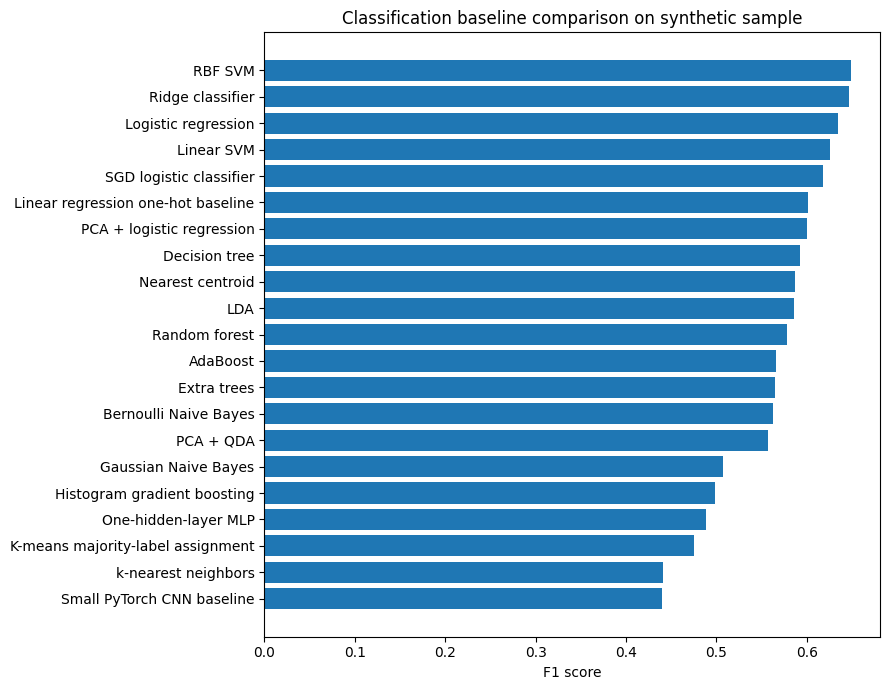

In [10]:
import matplotlib.pyplot as plt

plot_df = results_df.sort_values("f1", ascending=True)
plt.figure(figsize=(9, 7))
plt.barh(plot_df["model"], plot_df["f1"])
plt.xlabel("F1 score")
plt.title("Classification baseline comparison on synthetic sample")
plt.tight_layout()
plt.show()

## How to use the table

Use the linear models as sanity checks, tree ensembles and boosting as structured-data benchmarks, and neural models as experimental baselines. After selecting a candidate, rerun fairness checks by race/ethnicity, language, disability status, urbanicity, and household composition before using scores for any prioritization exercise.